# PokeAPI como grafo: capa de analisis competitivo

Extension del reporte principal hacia el **Pokemon competitivo** (Smogon singles, gen9 OU). Tres
aportes: consultas de teambuilding sobre el cuadro de tipos y los stats, una capa de **meta real**
de Smogon (usage stats) montada sobre los nodos que ya existen, y tres modelos predictivos
evaluados de forma critica y adversarial (con control de fuga).

Limitacion honesta transversal: el grafo base mide *potencial por tipos y stats base*, no el meta
real (no hay efectos de habilidades/moves, EVs, naturalezas ni items). La capa de Smogon agrega el
dato de uso real para cerrar parte de esa brecha.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
%matplotlib inline
driver = GraphDatabase.driver("bolt://localhost:7687", auth=None)
def q(query):
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(query)])
print("conectado")

conectado


## 1. Consultas de teambuilding (sin datos externos)

Explotan el cuadro de tipos (`EFFECTIVENESS`), los stats base y los movepools. Ninguna de las 9
consultas estructurales del reporte principal toca la mecanica de combate.

### Mejores tipados defensivos (mas resistencias e inmunidades)
El multiplicador frente a cada tipo atacante es el producto de los factores sobre los 1-2 tipos.

In [2]:
q("""
MATCH (p:Pokemon)-[:HAS_TYPE]->(def:Type) WHERE p.is_default
WITH p, collect(def) AS defs
MATCH (atk:Type)
OPTIONAL MATCH (atk)-[e:EFFECTIVENESS]->(d) WHERE d IN defs
WITH p, atk, reduce(f=1.0, x IN collect(e.factor/100.0) | f*x) AS mult
RETURN p.identifier AS pokemon,
       count(CASE WHEN mult=0.0 THEN 1 END) AS inmunidades,
       count(CASE WHEN mult>0 AND mult<1 THEN 1 END) AS resistencias,
       count(CASE WHEN mult>1 THEN 1 END) AS debilidades
ORDER BY (inmunidades+resistencias) DESC, debilidades ASC LIMIT 12
""")

,pokemon,inmunidades,resistencias,debilidades
0,magnemite,1,11,3
1,togedemaru,1,11,3
2,magnezone,1,11,3
3,magneton,1,11,3
4,gholdengo,3,9,4
5,doublade,3,9,4
6,honedge,3,9,4
7,aegislash-shield,3,9,4
8,magearna,2,9,2
9,tinkaton,2,9,2


### ¿Que amenazas son mas dificiles de murar por tipos?
Un counter resiste todos los STAB del threat. Menos counters = mas dificil de contrarrestar.
(Dato verificado en el camino: la intuicion de que Garchomp no tiene counters es falsa; los
duales como Skarmory steel/flying resisten ground y dragon a la vez.)

In [3]:
q("""
UNWIND ['dragapult','kingambit','garchomp','dragonite','tyranitar','great-tusk'] AS name
MATCH (threat:Pokemon {identifier:name})-[:HAS_TYPE]->(tt:Type)
WITH name, collect(DISTINCT tt) AS T
MATCH (c:Pokemon)-[:HAS_TYPE]->(ct:Type) WHERE c.is_default
WITH name, T, c, collect(ct) AS cdefs
WHERE ALL(tk IN T WHERE
      reduce(f=1.0, d IN cdefs | f * coalesce([(tk)-[e:EFFECTIVENESS]->(d) | e.factor/100.0][0], 1.0)) < 1.0)
RETURN name AS amenaza, count(c) AS counters_por_tipos ORDER BY counters_por_tipos
""")

,amenaza,counters_por_tipos
0,dragapult,10
1,garchomp,13
2,kingambit,26
3,dragonite,56
4,tyranitar,68
5,great-tusk,131


### Revenge-killers: lentos, fuertes, con prioridad STAB de dano

In [4]:
q("""
MATCH (p:Pokemon)-[:CAN_LEARN]->(m:Move)-[:MOVE_TYPE]->(mt:Type)
WHERE m.priority >= 1 AND m.power > 0 AND p.is_default
MATCH (p)-[:HAS_TYPE]->(pt:Type) WHERE pt = mt
MATCH (p)-[hs:HAS_STAT]->(:Stat {identifier:'speed'})
MATCH (p)-[ha:HAS_STAT]->(:Stat {identifier:'attack'})
WITH p.identifier AS poke, hs.base_stat AS speed, ha.base_stat AS ataque, collect(DISTINCT m.identifier) AS prio_stab
WHERE speed <= 60 AND ataque >= 110
RETURN poke, speed, ataque, prio_stab ORDER BY ataque DESC LIMIT 10
""")

,poke,speed,ataque,prio_stab
0,conkeldurr,45,140,"[upper-hand, mach-punch]"
1,crabominable,43,132,[upper-hand]
2,machamp,55,130,"[vacuum-wave, mach-punch]"
3,brute-bonnet,55,127,[sucker-punch]
4,golisopod,40,125,[first-impression]
5,crawdaunt,55,120,[aqua-jet]
6,hariyama,50,120,"[vacuum-wave, upper-hand]"
7,grimmsnarl,60,120,[sucker-punch]
8,cacturne,55,115,[sucker-punch]
9,doublade,35,110,[shadow-sneak]


### Calculadora de dano en Cypher puro
La formula completa de dano vive en una consulta. Charizard Flamethrower vs Venusaur da 209-246,
identico al damage calc oficial de Pokemon Showdown.

In [5]:
q("""
MATCH (atk:Pokemon {identifier:'charizard'})-[ha:HAS_STAT]->(:Stat {identifier:'special-attack'})
MATCH (def:Pokemon {identifier:'venusaur'})-[hd:HAS_STAT]->(:Stat {identifier:'special-defense'})
MATCH (m:Move {identifier:'flamethrower'})-[:MOVE_TYPE]->(mt:Type)
WITH atk, m, mt, ha, hd, CASE WHEN exists((atk)-[:HAS_TYPE]->(mt)) THEN 1.5 ELSE 1.0 END AS stab
MATCH (def:Pokemon {identifier:'venusaur'})-[:HAS_TYPE]->(dt:Type)
OPTIONAL MATCH (mt)-[e:EFFECTIVENESS]->(dt)
WITH m, ha, hd, stab, reduce(eff=1.0, f IN collect(coalesce(e.factor,100)/100.0) | eff*f) AS typeMult
WITH m, stab, typeMult,
     toInteger(floor((2.0*ha.base_stat + 31 + floor(252/4.0)))) + 5 AS A,
     toInteger(floor((2.0*hd.base_stat + 31 + floor(252/4.0)))) + 5 AS D
WITH m.power AS power, stab, typeMult,
     toInteger(floor(floor(floor(42.0*m.power*A/toFloat(D)) / 50))) + 2 AS baseDmg
RETURN power, stab, typeMult,
       toInteger(floor(baseDmg*stab*typeMult*0.85)) AS dmg_min,
       toInteger(floor(baseDmg*stab*typeMult*1.00)) AS dmg_max
""")

,power,stab,typeMult,dmg_min,dmg_max
0,90,1.5,2.0,209,246


## 2. Capa de meta real (Smogon usage stats)

Cargamos las usage stats mensuales de Smogon (gen9 OU, chaos.json) como subgrafo sobre los nodos
que ya existen: `(Pokemon)-[:USED_IN]->(:Format)`, `RUNS_MOVE`, `HOLDS_ITEM`, `USES_ABILITY`,
`TEAMMATE_OF`, `CHECKED_BY`. Se carga con `python pipeline/06_smogon.py`.

### Kit legal (aprendible) vs kit realmente usado en el meta

In [6]:
q("""
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:CAN_LEARN]->(legal:Move)
WITH p, u.usage AS uso_pct, count(DISTINCT legal) AS aprendibles
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(usado:Move)
RETURN p.identifier AS pokemon, uso_pct, aprendibles, count(DISTINCT usado) AS usados_en_meta
ORDER BY uso_pct DESC LIMIT 12
""")

,pokemon,uso_pct,aprendibles,usados_en_meta
0,great-tusk,33.727,58,13
1,zamazenta,28.680,68,12
2,gholdengo,27.633,45,11
3,dragonite,25.346,138,12
4,kingambit,25.270,58,5
5,gliscor,19.386,110,12
6,ting-lu,17.423,46,11
7,kyurem,17.035,86,13
8,ogerpon-wellspring-mask,16.466,62,14
9,dragapult,14.587,69,16


### Que tipos dominan el meta de OU

In [7]:
q("""
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
MATCH (p)-[:HAS_TYPE]->(t:Type)
RETURN t.identifier AS tipo, count(DISTINCT p) AS mons_en_OU, round(avg(u.usage),2) AS uso_promedio
ORDER BY mons_en_OU DESC LIMIT 10
""")

,tipo,mons_en_OU,uso_promedio
0,water,39,2.13
1,psychic,34,1.28
2,fighting,27,3.28
3,dark,27,3.10
4,grass,26,1.47
5,flying,26,3.71
6,steel,26,3.52
7,fire,23,2.31
8,dragon,21,4.41
9,poison,21,3.00


## 3. Modelos predictivos (evaluacion adversarial)

Tres modelos, todos con control de fuga: el **label shuffleado** debe dar AUC ~0.5 (si diera alto,
habria fuga). Las metricas se miden **out-of-fold** (cross-validation), nunca sobre el train.

### 3.1 ¿Se puede predecir si un Pokemon se usa en OU?
Ablacion: baseline (solo BST + legendario) vs + features de grafo. Y negativos **dificiles**
(solo fully-evolved no-legendarios) para no medir lo trivial (legendario vs pre-evo).

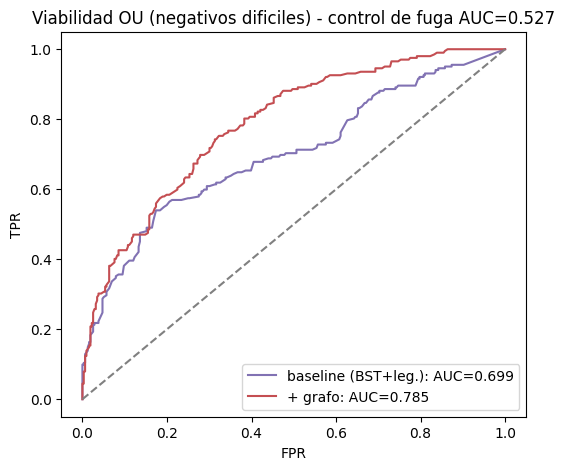

control de fuga (label shuffleado): AUC=0.527 (debe ser ~0.5)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

stats = q("MATCH (p:Pokemon {is_default:true})-[r:HAS_STAT]->(s:Stat) RETURN p.id AS id, s.identifier AS stat, r.base_stat AS v").pivot_table(index="id", columns="stat", values="v", fill_value=0)
stats["bst"] = stats.sum(axis=1)
meta = q("""MATCH (p:Pokemon {is_default:true})-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:CAN_LEARN]->(mv:Move) WITH p,sp,count(DISTINCT mv) AS movepool
OPTIONAL MATCH (p)-[:HAS_ABILITY]->(ab:Ability) WITH p,sp,movepool,count(DISTINCT ab) AS n_abil
OPTIONAL MATCH (p)-[:CAN_LEARN]->(pm:Move) WHERE pm.priority>0 AND pm.power>0
RETURN p.id AS id, movepool, n_abil, count(DISTINCT pm) AS prio_moves,
  CASE WHEN sp.is_legendary THEN 1 ELSE 0 END AS legendary,
  CASE WHEN sp.is_mythical THEN 1 ELSE 0 END AS mythical,
  CASE WHEN (sp)-[:EVOLVES_TO]->(:Species) THEN 0 ELSE 1 END AS fully_evolved""").set_index("id")
mt = q("""MATCH (p:Pokemon {is_default:true})-[:HAS_TYPE]->(def:Type) WITH p, collect(def) AS defs
MATCH (atk:Type) OPTIONAL MATCH (atk)-[e:EFFECTIVENESS]->(d) WHERE d IN defs
WITH p, atk, reduce(f=1.0,x IN collect(e.factor/100.0)|f*x) AS m
RETURN p.id AS id, sum(CASE WHEN m>1 THEN 1 ELSE 0 END) AS weak,
  sum(CASE WHEN m<1 AND m>0 THEN 1 ELSE 0 END) AS resist, sum(CASE WHEN m=0 THEN 1 ELSE 0 END) AS immune""").set_index("id")
lab = q("MATCH (p:Pokemon {is_default:true}) OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'}) RETURN p.id AS id, CASE WHEN u IS NULL THEN 0 ELSE 1 END AS in_ou").set_index("id")
D = stats.join([meta, mt, lab], how="inner").fillna(0)
base = ["bst","legendary"]
full = ["bst","hp","attack","defense","special-attack","special-defense","speed","legendary","mythical","fully_evolved","movepool","n_abil","prio_moves","weak","resist","immune"]
def oof(X,y,seed=42):
    return cross_val_predict(RandomForestClassifier(400,class_weight="balanced",random_state=seed,n_jobs=-1),X,y,cv=StratifiedKFold(5,shuffle=True,random_state=seed),method="predict_proba")[:,1]
hard = D[(D.in_ou==1)|((D.fully_evolved==1)&(D.legendary==0)&(D.mythical==0))]
yh = hard["in_ou"].astype(int)
plt.figure(figsize=(6,5))
for cols,labn,c in [(base,"baseline (BST+leg.)","#8172b3"),(full,"+ grafo","#c44e52")]:
    pr=oof(hard[cols],yh); a=roc_auc_score(yh,pr); fpr,tpr,_=roc_curve(yh,pr)
    plt.plot(fpr,tpr,color=c,label=f"{labn}: AUC={a:.3f}")
nulo=np.mean([roc_auc_score(p, oof(hard[full],p,seed=k)) for k in range(3) for p in [pd.Series(np.random.default_rng(k).permutation(yh.values),index=yh.index)]])
plt.plot([0,1],[0,1],"--",color="gray"); plt.legend(loc="lower right"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"Viabilidad OU (negativos dificiles) - control de fuga AUC={nulo:.3f}"); plt.show()
print(f"control de fuga (label shuffleado): AUC={nulo:.3f} (debe ser ~0.5)")

El baseline BST+legendario ya da AUC ~0.70; sumar features de grafo (movepool, distribucion de
stats, matchups) sube a ~0.79. El control de shuffle (~0.5) confirma que ese salto es senal real.

### 3.2 Recomendacion de teammates: ¿que predice el co-uso real?
Link prediction sobre `TEAMMATE_OF`. Contrastamos popularidad (ambos se usan mucho) vs la
complementariedad defensiva calculada en nuestro grafo de tipos vs la topologia de co-ocurrencia.

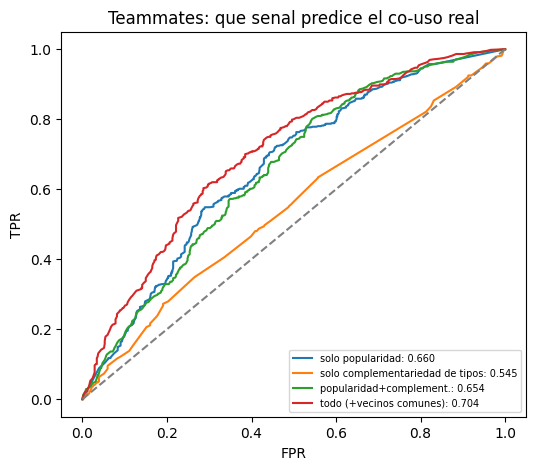

In [9]:
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(42)
tm = q("MATCH (a:Pokemon)-[t:TEAMMATE_OF]->(b:Pokemon) RETURN a.id AS a, b.id AS b")
usage = q("MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'}) RETURN p.id AS id, u.usage AS usage").set_index("id")["usage"].to_dict()
nodeset = set(usage); nodes = sorted(nodeset)
prof = q("""MATCH (p:Pokemon)-[:USED_IN]->(:Format {tier:'gen9ou'}) MATCH (p)-[:HAS_TYPE]->(def:Type)
WITH p, collect(def) AS defs MATCH (atk:Type) OPTIONAL MATCH (atk)-[e:EFFECTIVENESS]->(d) WHERE d IN defs
WITH p, atk, reduce(f=1.0,x IN collect(e.factor/100.0)|f*x) AS m
RETURN p.id AS id, [a IN collect(CASE WHEN m>=2 THEN atk.identifier END) WHERE a IS NOT NULL] AS weak,
  [a IN collect(CASE WHEN m<1 THEN atk.identifier END) WHERE a IS NOT NULL] AS resist""")
weak={r.id:set(r.weak) for r in prof.itertuples()}; resist={r.id:set(r.resist) for r in prof.itertuples()}
edge_set={(min(a,b),max(a,b)) for a,b in zip(tm.a,tm.b) if a in nodeset and b in nodeset}
adj={n:set() for n in nodes}
for a,b in edge_set: adj[a].add(b); adj[b].add(a)
def comp(u,v):
    wu,wv,ru,rv=weak.get(u,set()),weak.get(v,set()),resist.get(u,set()),resist.get(v,set())
    return ((len(wu&rv)/len(wu) if wu else 1)+(len(wv&ru)/len(wv) if wv else 1))/2
def feats(P): return np.array([[usage.get(u,0)*usage.get(v,0), comp(u,v), len(adj[u]&adj[v])] for u,v in P],dtype=float)
pos=np.array(list(edge_set))
def negs(k):
    o=set(); nl=np.array(nodes)
    while len(o)<k:
        u,v=rng.choice(nl,2,replace=False); e=(int(min(u,v)),int(max(u,v)))
        if e not in edge_set: o.add(e)
    return np.array(list(o))
neg=negs(len(pos)); ptr,pte=train_test_split(pos,test_size=0.25,random_state=42); ntr,nte=train_test_split(neg,test_size=0.25,random_state=42)
ytr=np.r_[np.ones(len(ptr)),np.zeros(len(ntr))]; yte=np.r_[np.ones(len(pte)),np.zeros(len(nte))]
Xtr,Xte=feats(np.vstack([ptr,ntr])),feats(np.vstack([pte,nte]))
plt.figure(figsize=(6,5))
for nombre,idx in {"solo popularidad":[0],"solo complementariedad de tipos":[1],"popularidad+complement.":[0,1],"todo (+vecinos comunes)":[0,1,2]}.items():
    m=RandomForestClassifier(300,random_state=42,n_jobs=-1).fit(Xtr[:,idx],ytr); p=m.predict_proba(Xte[:,idx])[:,1]
    a=roc_auc_score(yte,p); fpr,tpr,_=roc_curve(yte,p); plt.plot(fpr,tpr,label=f"{nombre}: {a:.3f}")
plt.plot([0,1],[0,1],"--",color="gray"); plt.legend(fontsize=7,loc="lower right"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Teammates: que senal predice el co-uso real"); plt.show()

**Hallazgo adversarial:** la complementariedad defensiva de tipos **sola** apenas supera el azar
(~0.55) y no mejora sobre popularidad. La idea intuitiva de que los buenos compañeros se cubren las
debilidades de tipo **no** explica el co-uso real; lo que lo predice es la estructura de
co-ocurrencia (vecinos comunes). El grafo de tipos describe el juego, no el meta.

### 3.3 Clustering de roles por stats base
No supervisado sobre las proporciones de los 6 stats (forma del spread, no poder bruto), para que
un frail-veloz y un muro-lento caigan en clusters distintos sin importar su BST.

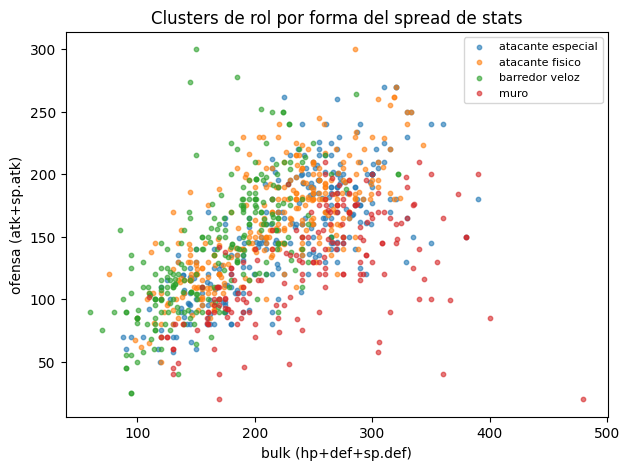

rol
atacante fisico      321
atacante especial    277
barredor veloz       246
muro                 181


In [10]:
from sklearn.cluster import KMeans
so=["hp","attack","defense","special-attack","special-defense","speed"]
R=q("MATCH (p:Pokemon {is_default:true})-[r:HAS_STAT]->(s:Stat) RETURN p.id AS id, p.identifier AS nombre, s.identifier AS stat, r.base_stat AS v").pivot_table(index=["id","nombre"],columns="stat",values="v",fill_value=0)[so]
prop=R.div(R.sum(axis=1),axis=0)
km=KMeans(5,random_state=42,n_init=10).fit(prop.values); R["cluster"]=km.labels_
cent=prop.groupby(km.labels_).mean()
ejes=pd.DataFrame({"speed":cent["speed"],"ofensa":cent["attack"]+cent["special-attack"],"bulk":cent["hp"]+cent["defense"]+cent["special-defense"]})
z=(ejes-ejes.mean())/ejes.std()
def lab(c):
    dom=z.loc[c].idxmax(); fis=cent.loc[c,"attack"]>=cent.loc[c,"special-attack"]
    if dom=="speed": return "barredor veloz" if ejes.loc[c,"ofensa"]>=ejes.mean()["ofensa"] else "veloz fragil"
    if dom=="bulk": return "muro" if z.loc[c,"speed"]<0 else "tanque"
    return "atacante fisico" if fis else "atacante especial"
R["rol"]=R["cluster"].map({c:lab(c) for c in cent.index})
R["ofensa"]=R["attack"]+R["special-attack"]; R["bulk"]=R["hp"]+R["defense"]+R["special-defense"]
plt.figure(figsize=(7,5))
for r in sorted(R["rol"].unique()):
    s=R[R["rol"]==r]; plt.scatter(s["bulk"],s["ofensa"],s=10,alpha=0.6,label=r)
plt.xlabel("bulk (hp+def+sp.def)"); plt.ylabel("ofensa (atk+sp.atk)"); plt.legend(fontsize=8)
plt.title("Clusters de rol por forma del spread de stats"); plt.show()
print(R["rol"].value_counts().to_string())

Caveat honesto: es stat-spread crudo. El rol meta real depende del typing, los items y los EVs
que el grafo no tiene; sirve como esqueleto, no como tier de Smogon.

## 4. Como se verifica que las metricas son correctas

- **Out-of-fold**: cada Pokemon lo predice un modelo de un fold que NO lo vio (`cross_val_predict`),
  asi el AUC nunca se mide sobre el train.
- **Control de fuga**: con el label permutado al azar el AUC cae a ~0.5 (viabilidad 0.53, teammates
  0.49). Si hubiera fuga, seguiria alto. Promediado sobre varias permutaciones para estabilidad.
- **Baselines y ablacion**: cada modelo se compara contra un baseline trivial (BST, popularidad) y
  un Dummy (AUC=0.5 por definicion), para aislar cuanto aporta el grafo.
- **Negativos dificiles**: en viabilidad, los negativos son Pokemon comparables (fully-evolved no
  legendarios), no pre-evos triviales, para que el AUC no infle midiendo lo obvio.


In [11]:
driver.close()
print("fin del reporte competitivo")

fin del reporte competitivo
